### Understanding the Bank of England Gilt Yield Data

This notebook is the first stage of the LDI crisis time-series project.

The goal here is **not to fit forecasting models yet**. We first want to understand exactly what data we have, whether it has been read correctly, what dates it covers, whether observations are missing or duplicated, and how the 10-year nominal zero-coupon gilt yield behaved around the September 2022 LDI crisis.

[The Bank of England Gilt Yield Data](https://www.bankofengland.co.uk/boeapps/database/fromshowcolumns.asp?CSVF=TT&DAT=RNG&FD=1&FM=Jan&FNY=Y&FY=2014&Filter=N&FromSeries=1&SeriesCodes=IUDMNZC&TD=31&TM=Dec&TY=2024&ToSeries=50&Travel=NIxAZxSUx&UsingCodes=Y&VPD=Y&html.x=66&html.y=26&title=IUDMNZC&utm)

Expected Bank of England series:

- **Series code:** `IUDMNZC`
- **Variable:** 10-year nominal zero-coupon yield on UK government securities
- **Frequency:** daily observations on Bank of England business/market dates
- **Units:** percent

### Import packages


In [35]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import warnings
warnings.filterwarnings("ignore")

pd.set_option("display.max_rows", 100)
pd.set_option("display.max_columns", 20)
pd.set_option("display.width", 120)

### 2. Locate the CSV file

In [36]:
DATA_PATH = (
    Path.home()
    / "Downloads"
    / "Dissertation"
    / "Bank of England Database.csv"
)

print("Looking for:")
print(DATA_PATH)
print()
print("File exists:", DATA_PATH.exists())

if not DATA_PATH.exists():
    raise FileNotFoundError(
        f"Could not find the file at:\n{DATA_PATH}\n\n"
        "Check the folder and filename, then edit DATA_PATH if necessary."
    )

Looking for:
/Users/qp252008/Downloads/Dissertation/Bank of England Database.csv

File exists: True


### Look at the raw file before asking pandas to interpret it

This is useful because CSV files downloaded from official databases can sometimes contain unusual headers or metadata.

In [37]:
with open(DATA_PATH, "r", encoding="utf-8-sig", errors="replace") as f:
    for i in range(12):
        line = f.readline()
        if not line:
            break
        print(f"{i + 1:02d}: {line.rstrip()}")


01: "Date","Yield from British Government Securities, 10 year Nominal Zero Coupon 						IUDMNZC"
02: "31 Dec 24","4.5701"
03: "30 Dec 24","4.5959"
04: "27 Dec 24","4.6235"
05: "24 Dec 24","4.5926"
06: "23 Dec 24","4.5569"
07: "20 Dec 24","4.5181"
08: "19 Dec 24","4.5773"
09: "18 Dec 24","4.5372"
10: "17 Dec 24","4.4999"
11: "16 Dec 24","4.4232"
12: "13 Dec 24","4.3913"


### Read the CSV


In [38]:
df_raw = pd.read_csv(DATA_PATH)

print("Shape:", df_raw.shape)
df_raw.head(10)


Shape: (2779, 2)


,Date,"Yield from British Government Securities, 10 year Nominal Zero Coupon \t\t\t\t\t\tIUDMNZC"
0,31 Dec 24,4.5701
1,30 Dec 24,4.5959
2,27 Dec 24,4.6235
3,24 Dec 24,4.5926
4,23 Dec 24,4.5569
5,20 Dec 24,4.5181
6,19 Dec 24,4.5773
7,18 Dec 24,4.5372
8,17 Dec 24,4.4999
9,16 Dec 24,4.4232


### Inspect the structure

We want to know:

- how many rows and columns there are;
- the exact column names;
- the pandas data type of each column;
- whether the first and last observations look sensible.

In [39]:
print("Columns:")
print(df_raw.columns.tolist())

print("\nData types:")
print(df_raw.dtypes)

print("\nDataFrame information:")
df_raw.info()

Columns:
['Date', 'Yield from British Government Securities, 10 year Nominal Zero Coupon \t\t\t\t\t\tIUDMNZC']

Data types:
Date                                                                                             str
Yield from British Government Securities, 10 year Nominal Zero Coupon \t\t\t\t\t\tIUDMNZC    float64
dtype: object

DataFrame information:
<class 'pandas.DataFrame'>
RangeIndex: 2779 entries, 0 to 2778
Data columns (total 2 columns):
 #   Column                                                                               Non-Null Count  Dtype  
---  ------                                                                               --------------  -----  
 0   Date                                                                                 2779 non-null   str    
 1   Yield from British Government Securities, 10 year Nominal Zero Coupon 						IUDMNZC  2779 non-null   float64
dtypes: float64(1), str(1)
memory usage: 43.6 KB


In [40]:
print("First observations:")
display(df_raw.head())

print("\nLast observations:")
display(df_raw.tail())

First observations:


,Date,"Yield from British Government Securities, 10 year Nominal Zero Coupon \t\t\t\t\t\tIUDMNZC"
0,31 Dec 24,4.5701
1,30 Dec 24,4.5959
2,27 Dec 24,4.6235
3,24 Dec 24,4.5926
4,23 Dec 24,4.5569



Last observations:


,Date,"Yield from British Government Securities, 10 year Nominal Zero Coupon \t\t\t\t\t\tIUDMNZC"
2774,08 Jan 14,3.1140
2775,07 Jan 14,3.0831
2776,06 Jan 14,3.1053
2777,03 Jan 14,3.1579
2778,02 Jan 14,3.1625


### Verify that this is the correct BoE series

In [41]:
DATE_COL = "Date"

YIELD_COL = (
    "Yield from British Government Securities, "
    "10 year Nominal Zero Coupon \t\t\t\t\t\tIUDMNZC"
)

required_columns = {DATE_COL, YIELD_COL}
missing_columns = required_columns.difference(df_raw.columns)

if missing_columns:
    raise ValueError(
        "Expected columns were not found.\n"
        f"Missing: {sorted(missing_columns)}\n"
        f"Actual columns: {df_raw.columns.tolist()}"
    )

print("Correct expected columns found.")
print(f"Date column:  {DATE_COL}")
print(f"Yield column: {YIELD_COL}")

Correct expected columns found.
Date column:  Date
Yield column: Yield from British Government Securities, 10 year Nominal Zero Coupon 						IUDMNZC


### Keep only the variables needed for the univariate gilt-yield analysis

We rename them to simpler names for the rest of the project while retaining the original series code in the raw DataFrame.

In [42]:
boe = df_raw[[DATE_COL, YIELD_COL]].copy()

boe = boe.rename(
    columns={
        DATE_COL: "date",
        YIELD_COL: "yield_10y"
    }
)

boe.head()

,date,yield_10y
0,31 Dec 24,4.5701
1,30 Dec 24,4.5959
2,27 Dec 24,4.6235
3,24 Dec 24,4.5926
4,23 Dec 24,4.5569


### Convert the date and yield columns to usable types

A date stored as text cannot be handled correctly as a time-series index.

The yield must also be numeric before we calculate differences, averages, or fit models later.

In [43]:
boe["date_raw"] = boe["date"]
boe["yield_raw"] = boe["yield_10y"]

boe["date"] = pd.to_datetime(
    boe["date"],
    dayfirst=True,
    errors="coerce"
)

boe["yield_10y"] = pd.to_numeric(
    boe["yield_10y"],
    errors="coerce"
)

boe[["date", "yield_10y", "date_raw", "yield_raw"]].head()

,date,yield_10y,date_raw,yield_raw
0,2024-12-31,4.5701,31 Dec 24,4.5701
1,2024-12-30,4.5959,30 Dec 24,4.5959
2,2024-12-27,4.6235,27 Dec 24,4.6235
3,2024-12-24,4.5926,24 Dec 24,4.5926
4,2024-12-23,4.5569,23 Dec 24,4.5569


### Check whether conversion created missing values

If a non-missing raw value becomes `NaT` or `NaN`, pandas failed to interpret that observation. We should inspect such rows rather than deleting them automatically.

In [44]:
bad_dates = boe[
    boe["date"].isna()
    & boe["date_raw"].notna()
]

bad_yields = boe[
    boe["yield_10y"].isna()
    & boe["yield_raw"].notna()
]

print("Rows with unparsed dates:", len(bad_dates))
print("Rows with non-numeric yield values:", len(bad_yields))

if len(bad_dates) > 0:
    display(bad_dates)

if len(bad_yields) > 0:
    display(bad_yields)

Rows with unparsed dates: 0
Rows with non-numeric yield values: 0


### Missing values

In [45]:
missing = boe[["date", "yield_10y"]].isna().sum().to_frame("missing_count")
missing["missing_percent"] = 100 * missing["missing_count"] / len(boe)

missing

,missing_count,missing_percent
date,0,0.0
yield_10y,0,0.0


### Duplicate dates

A univariate daily yield series should normally have one observation per date.

In [46]:
duplicate_dates = boe[boe["date"].duplicated(keep=False)].sort_values("date")

print("Number of duplicated date rows:", len(duplicate_dates))

if len(duplicate_dates) > 0:
    display(duplicate_dates)


Number of duplicated date rows: 0


### Create the clean working copy

At this stage we only remove rows whose date or yield could not be interpreted, sort chronologically, and verify that dates are unique.

We are **not imputing missing market dates**. Weekends and holidays are not automatically errors.

In [47]:
boe_clean = (
    boe[["date", "yield_10y"]]
    .dropna(subset=["date", "yield_10y"])
    .sort_values("date")
    .drop_duplicates(subset="date", keep="first")
    .reset_index(drop=True)
)

print("Raw rows:", len(boe))
print("Usable rows:", len(boe_clean))
print("Rows removed:", len(boe) - len(boe_clean))

boe_clean.head()

Raw rows: 2779
Usable rows: 2779
Rows removed: 0


,date,yield_10y
0,2014-01-02,3.1625
1,2014-01-03,3.1579
2,2014-01-06,3.1053
3,2014-01-07,3.0831
4,2014-01-08,3.1140


### Basic sample information

In [48]:
print("First date:", boe_clean["date"].min().date())
print("Last date: ", boe_clean["date"].max().date())
print("Number of observations:", len(boe_clean))

calendar_span = (
    boe_clean["date"].max() - boe_clean["date"].min()
).days

print("Calendar span in days:", calendar_span)

First date: 2014-01-02
Last date:  2024-12-31
Number of observations: 2779
Calendar span in days: 4016


### Descriptive statistics of the yield level

These statistics describe the **level of the yield over the full sample**. They are not yet a volatility model.

In [49]:
boe_clean["yield_10y"].describe()

count    2779.000000
mean        1.913977
std         1.249740
min         0.111400
25%         0.982000
50%         1.510300
75%         2.795300
max         4.665100
Name: yield_10y, dtype: float64

In [50]:
full_sample_stats = pd.Series({
    "count": boe_clean["yield_10y"].count(),
    "mean": boe_clean["yield_10y"].mean(),
    "median": boe_clean["yield_10y"].median(),
    "std": boe_clean["yield_10y"].std(),
    "variance": boe_clean["yield_10y"].var(),
    "minimum": boe_clean["yield_10y"].min(),
    "maximum": boe_clean["yield_10y"].max(),
    "range": boe_clean["yield_10y"].max() - boe_clean["yield_10y"].min(),
    "q1": boe_clean["yield_10y"].quantile(0.25),
    "q3": boe_clean["yield_10y"].quantile(0.75),
})

full_sample_stats["IQR"] = (
    full_sample_stats["q3"]
    - full_sample_stats["q1"]
)

full_sample_stats

count       2779.000000
mean           1.913977
median         1.510300
std            1.249740
variance       1.561850
minimum        0.111400
maximum        4.665100
range          4.553700
q1             0.982000
q3             2.795300
IQR            1.813300
dtype: float64

#### Descriptive Statistics

- The dataset contains 2,779 daily observations of the UK 10-year nominal zero-coupon yield from 2014 to 2024.

- The average yield is 1.91%, while the median is lower at 1.51%, suggesting that higher-yield periods pull the mean upward.

- The standard deviation is 1.25 percentage points, indicating substantial variation in yield levels over the full sample.

- Yields range from 0.11% to 4.67%, with the middle 50% of observations lying between 0.98% and 2.80%.

### Understand the observation calendar

The BoE data are market/business-day observations, not a perfectly regular seven-day-per-week series.

We therefore inspect the gaps rather than automatically filling them.

In [51]:
boe_clean["calendar_gap_days"] = boe_clean["date"].diff().dt.days

print("Calendar gap distribution:")
display(
    boe_clean["calendar_gap_days"]
    .value_counts()
    .sort_index()
    .to_frame("number_of_gaps")
)

print(
    "\nMedian gap:",
    boe_clean["calendar_gap_days"].median(),
    "calendar day(s)"
)

Calendar gap distribution:


,number_of_gaps
calendar_gap_days,
1.0,2198
2.0,3
3.0,516
4.0,41
5.0,20



Median gap: 1.0 calendar day(s)


In [52]:
boe_clean["day_name"] = boe_clean["date"].dt.day_name()

day_counts = (
    boe_clean["day_name"]
    .value_counts()
    .reindex(
        ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"],
        fill_value=0
    )
)

day_counts

day_name
Monday       518
Tuesday      567
Wednesday    569
Thursday     569
Friday       556
Saturday       0
Sunday         0
Name: count, dtype: int64

### Plot the full yield series

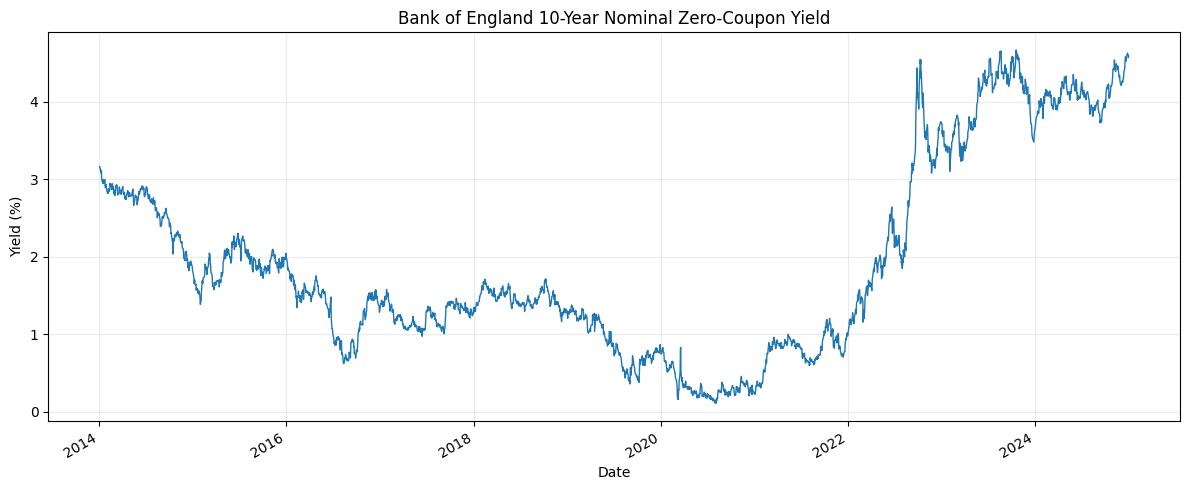

In [53]:
fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(
    boe_clean["date"],
    boe_clean["yield_10y"],
    linewidth=1
)

ax.set_title("Bank of England 10-Year Nominal Zero-Coupon Yield")
ax.set_xlabel("Date")
ax.set_ylabel("Yield (%)")
ax.grid(alpha=0.25)

fig.autofmt_xdate()
plt.tight_layout()
plt.show()

#### Initial Time-Series Observations

The 10-year nominal zero-coupon yield changes substantially over the 2014–2024 sample. Yields generally declined from 2014 to 2020–2021 before rising sharply during 2022 and remaining elevated through 2023–2024. This indicates that the yield level may not have a constant mean over time, which will later be examined using formal stationarity tests.

The data are observed on business/market days rather than every calendar day. Most observations are one day apart, while three-day gaps largely represent weekends. There are no Saturday or Sunday observations. These calendar gaps should therefore not automatically be treated as missing data.

### Inspect 2022 separately

In [54]:
boe_2022 = boe_clean[
    boe_clean["date"].between(
        "2022-01-01",
        "2022-12-31"
    )
].copy()

print("2022 observations:", len(boe_2022))
boe_2022.head()

2022 observations: 250


,date,yield_10y,calendar_gap_days,day_name
2024,2022-01-04,1.0842,4.0,Tuesday
2025,2022-01-05,1.0863,1.0,Wednesday
2026,2022-01-06,1.1575,1.0,Thursday
2027,2022-01-07,1.1849,1.0,Friday
2028,2022-01-10,1.1990,3.0,Monday


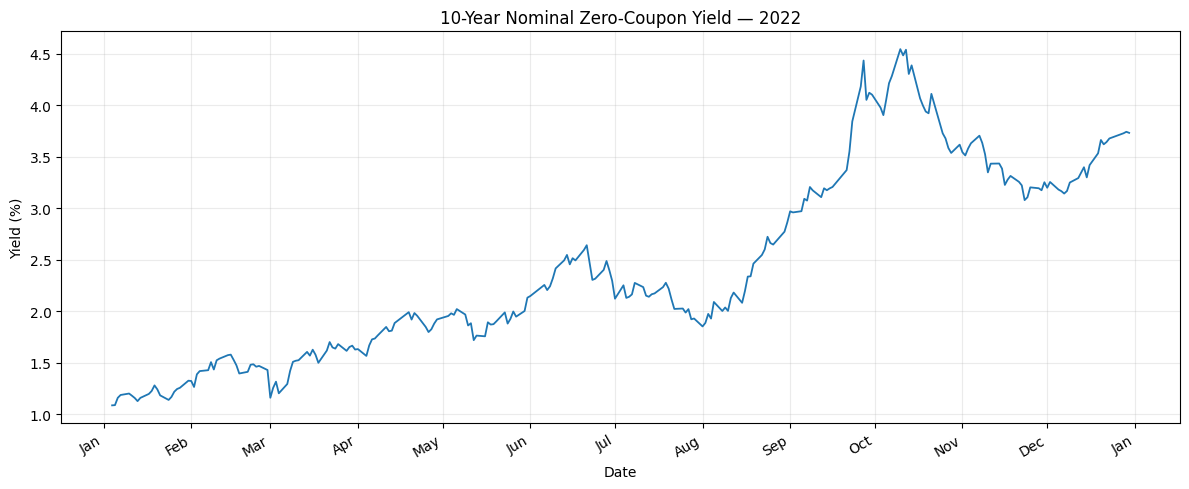

In [55]:
fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(
    boe_2022["date"],
    boe_2022["yield_10y"],
    linewidth=1.3
)

ax.set_title("10-Year Nominal Zero-Coupon Yield — 2022")
ax.set_xlabel("Date")
ax.set_ylabel("Yield (%)")
ax.grid(alpha=0.25)

ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b"))

fig.autofmt_xdate()
plt.tight_layout()
plt.show()

### Mark the two central LDI-crisis dates

For the project we will use:

- **23 September 2022:** UK mini-budget
- **28 September 2022:** Bank of England announced and began temporary long-dated gilt purchases

These dates matter later when we construct pre-crisis and intervention counterfactual forecasts.

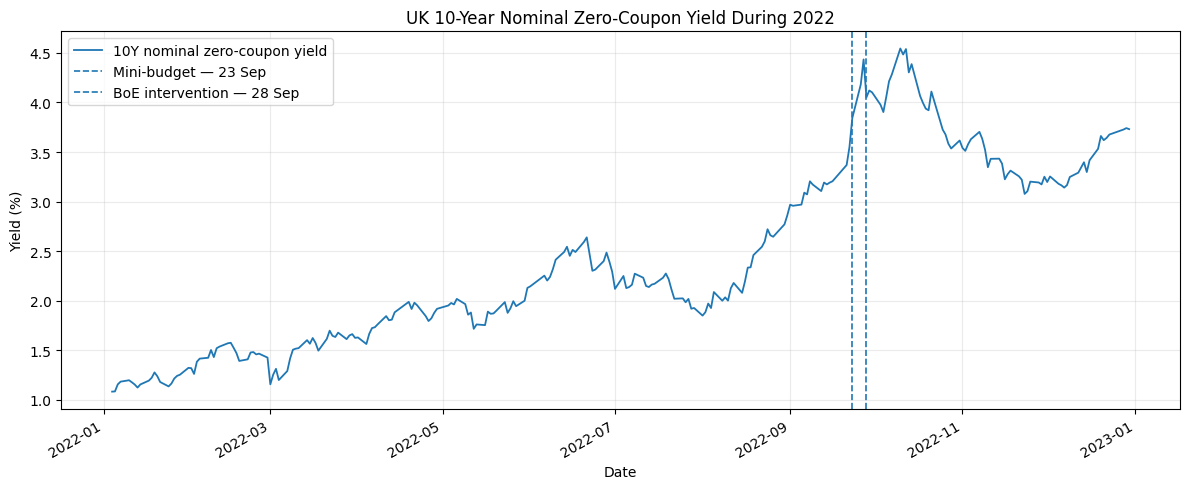

In [56]:
MINI_BUDGET_DATE = pd.Timestamp("2022-09-23")
BOE_INTERVENTION_DATE = pd.Timestamp("2022-09-28")

fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(
    boe_2022["date"],
    boe_2022["yield_10y"],
    linewidth=1.3,
    label="10Y nominal zero-coupon yield"
)

ax.axvline(
    MINI_BUDGET_DATE,
    linestyle="--",
    linewidth=1.2,
    label="Mini-budget — 23 Sep"
)

ax.axvline(
    BOE_INTERVENTION_DATE,
    linestyle="--",
    linewidth=1.2,
    label="BoE intervention — 28 Sep"
)

ax.set_title("UK 10-Year Nominal Zero-Coupon Yield During 2022")
ax.set_xlabel("Date")
ax.set_ylabel("Yield (%)")
ax.grid(alpha=0.25)
ax.legend()

fig.autofmt_xdate()
plt.tight_layout()
plt.show()

#### 2022 Yield Behaviour

There are 250 observations in 2022. The 10-year nominal zero-coupon yield increased substantially over the year, rising from around 1.1% in January to above 4% during the September–October period. A particularly sharp movement occurred around the mini-budget announcement on 23 September. The yield continued to rise over the following trading days before falling on 28 September, when the Bank of England intervened in the gilt market. Large movements continued afterwards, showing that market conditions remained volatile even after the intervention.

### Zoom in on the crisis window

Looking at the actual rows around the event dates is essential. This also protects us from the date-shifting problem seen in the earlier dissertation.

In [57]:
crisis_window = boe_clean[
    boe_clean["date"].between(
        "2022-09-01",
        "2022-10-31"
    )
].copy()

crisis_window

,date,yield_10y,calendar_gap_days,day_name
2190,2022-09-01,2.9689,1.0,Thursday
2191,2022-09-02,2.9584,1.0,Friday
2192,2022-09-05,2.9703,3.0,Monday
2193,2022-09-06,3.0907,1.0,Tuesday
2194,2022-09-07,3.0732,1.0,Wednesday
2195,2022-09-08,3.2052,1.0,Thursday
2196,2022-09-09,3.1724,1.0,Friday
2197,2022-09-12,3.1065,3.0,Monday
2198,2022-09-13,3.1928,1.0,Tuesday
2199,2022-09-14,3.1740,1.0,Wednesday


In [58]:
event_window = boe_clean[
    boe_clean["date"].between(
        "2022-09-20",
        "2022-10-05"
    )
].copy()

event_window

,date,yield_10y,calendar_gap_days,day_name
2202,2022-09-20,3.3364,4.0,Tuesday
2203,2022-09-21,3.3695,1.0,Wednesday
2204,2022-09-22,3.5516,1.0,Thursday
2205,2022-09-23,3.8426,1.0,Friday
2206,2022-09-26,4.1817,3.0,Monday
2207,2022-09-27,4.4341,1.0,Tuesday
2208,2022-09-28,4.0517,1.0,Wednesday
2209,2022-09-29,4.1210,1.0,Thursday
2210,2022-09-30,4.1021,1.0,Friday
2211,2022-10-03,3.9766,3.0,Monday


### September–October 2022 Crisis Window

The crisis window shows a rapid increase in the 10-year nominal zero-coupon yield after the mini-budget on 23 September. The yield rose from 3.84% on 23 September to 4.43% by 27 September. On 28 September, the date of the Bank of England intervention, it fell sharply to 4.05%. Yields then increased again during early October, reaching around 4.5%, before declining through the second half of the month. This suggests that the intervention coincided with an immediate reduction in yields, although market instability continued for several weeks.

### Plot the crisis window

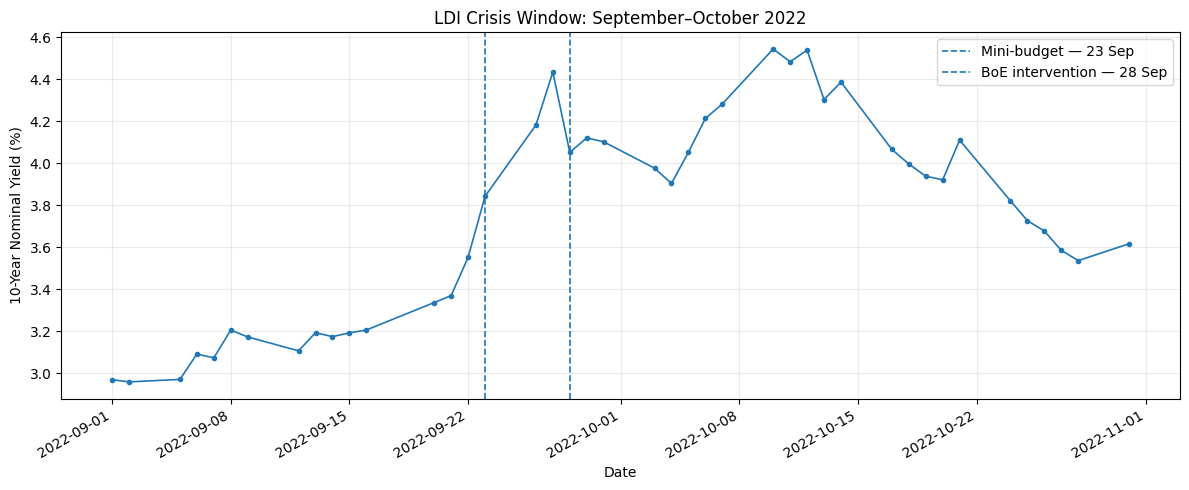

In [59]:
fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(
    crisis_window["date"],
    crisis_window["yield_10y"],
    marker="o",
    markersize=3,
    linewidth=1.2
)

ax.axvline(
    MINI_BUDGET_DATE,
    linestyle="--",
    linewidth=1.2,
    label="Mini-budget — 23 Sep"
)

ax.axvline(
    BOE_INTERVENTION_DATE,
    linestyle="--",
    linewidth=1.2,
    label="BoE intervention — 28 Sep"
)

ax.set_title("LDI Crisis Window: September–October 2022")
ax.set_xlabel("Date")
ax.set_ylabel("10-Year Nominal Yield (%)")
ax.grid(alpha=0.25)
ax.legend()

fig.autofmt_xdate()
plt.tight_layout()
plt.show()

### Calculate daily changes in the yield

For modelling the **mean**, we may later work with the yield level or differences depending on stationarity.

For volatility models such as ARCH and GARCH, changes/innovations are generally more relevant than simply taking the variance of the yield level.

Because the yield is stored in percentage points:

- a change of `0.01` percentage points = **1 basis point**
- therefore `daily change × 100` gives the change in basis points.

In [60]:
boe_clean["yield_change"] = boe_clean["yield_10y"].diff()
boe_clean["yield_change_bps"] = boe_clean["yield_change"] * 100

boe_clean[
    ["date", "yield_10y", "yield_change", "yield_change_bps"]
].head(10)

,date,yield_10y,yield_change,yield_change_bps
0,2014-01-02,3.1625,NaN,NaN
1,2014-01-03,3.1579,-0.0046,-0.46
2,2014-01-06,3.1053,-0.0526,-5.26
3,2014-01-07,3.0831,-0.0222,-2.22
4,2014-01-08,3.1140,0.0309,3.09
5,2014-01-09,3.1076,-0.0064,-0.64
6,2014-01-10,3.0124,-0.0952,-9.52
7,2014-01-13,2.9638,-0.0486,-4.86
8,2014-01-14,2.9593,-0.0045,-0.45
9,2014-01-15,2.9968,0.0375,3.75


### Daily Yield Changes

Daily yield changes measure the difference between the current yield and the previous trading-day yield. The same changes are also expressed in basis points, where 1 basis point is equal to 0.01 percentage points. For example, the yield fell from 3.1579% to 3.1053% on 6 January 2014, corresponding to a change of about -5.26 basis points. The first observation has no daily change because there is no earlier observation available for comparison.

### Largest daily yield movements

This immediately tells us when the most extreme changes in the sample occurred.

In [61]:
largest_moves = (
    boe_clean
    .dropna(subset=["yield_change_bps"])
    .assign(abs_change_bps=lambda x: x["yield_change_bps"].abs())
    .nlargest(15, "abs_change_bps")
    [
        [
            "date",
            "yield_10y",
            "yield_change_bps",
            "abs_change_bps"
        ]
    ]
)

largest_moves

,date,yield_10y,yield_change_bps,abs_change_bps
2208,2022-09-28,4.0517,-38.24,38.24
2206,2022-09-26,4.1817,33.91,33.91
2221,2022-10-17,4.0661,-32.07,32.07
2296,2023-02-02,3.1011,-31.58,31.58
1573,2020-03-20,0.5273,-30.52,30.52
2205,2022-09-23,3.8426,29.10,29.10
2226,2022-10-24,3.8207,-28.94,28.94
2064,2022-03-01,1.1579,-26.95,26.95
626,2016-06-24,1.2172,-26.38,26.38
2216,2022-10-10,4.5445,26.19,26.19


#### Largest Daily Yield Movements

- The largest daily movement in the sample occurred on 28 September 2022, when the 10-year nominal zero-coupon yield fell by 38.24 basis points.

- Several of the largest absolute changes are concentrated around the 2022 LDI crisis, including increases of 29.10 basis points on 23 September, 33.91 basis points on 26 September and 25.24 basis points on 27 September. 

- Large movements also occurred outside the crisis period, such as during March 2020 and February 2023, showing that extreme changes are not unique to the LDI episode.

### Plot daily changes

This is our first visual look at whether volatility appears constant over time or clustered into calm and turbulent periods.

We are only observing the pattern here.

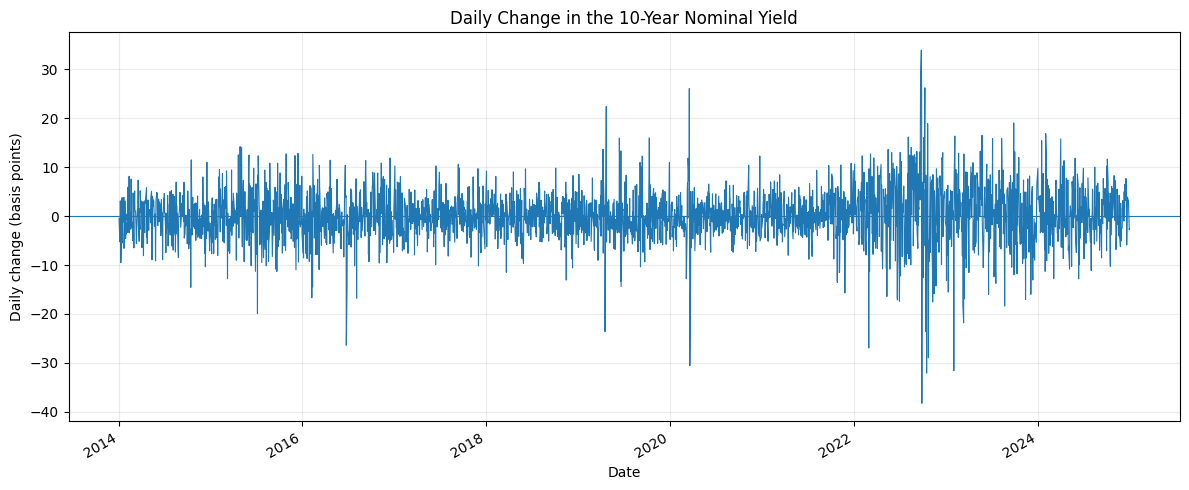

In [62]:
fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(
    boe_clean["date"],
    boe_clean["yield_change_bps"],
    linewidth=0.8
)

ax.axhline(0, linewidth=0.8)

ax.set_title("Daily Change in the 10-Year Nominal Yield")
ax.set_xlabel("Date")
ax.set_ylabel("Daily change (basis points)")
ax.grid(alpha=0.25)

fig.autofmt_xdate()
plt.tight_layout()
plt.show()

### Daily changes around the LDI crisis

In [63]:
crisis_changes = boe_clean[
    boe_clean["date"].between(
        "2022-09-20",
        "2022-10-05"
    )
][
    [
        "date",
        "yield_10y",
        "yield_change_bps"
    ]
].copy()

crisis_changes

,date,yield_10y,yield_change_bps
2202,2022-09-20,3.3364,13.08
2203,2022-09-21,3.3695,3.31
2204,2022-09-22,3.5516,18.21
2205,2022-09-23,3.8426,29.10
2206,2022-09-26,4.1817,33.91
2207,2022-09-27,4.4341,25.24
2208,2022-09-28,4.0517,-38.24
2209,2022-09-29,4.1210,6.93
2210,2022-09-30,4.1021,-1.89
2211,2022-10-03,3.9766,-12.55


### Compare the exact event-day observations

This does not yet claim causality. It simply records what the measured yield was on the relevant market dates.

In [64]:
important_dates = pd.to_datetime([
    "2022-09-22",
    "2022-09-23",
    "2022-09-26",
    "2022-09-27",
    "2022-09-28",
    "2022-09-29",
    "2022-09-30",
    "2022-10-03",
])

important_observations = boe_clean[
    boe_clean["date"].isin(important_dates)
][
    [
        "date",
        "yield_10y",
        "yield_change_bps"
    ]
].copy()

important_observations


,date,yield_10y,yield_change_bps
2204,2022-09-22,3.5516,18.21
2205,2022-09-23,3.8426,29.10
2206,2022-09-26,4.1817,33.91
2207,2022-09-27,4.4341,25.24
2208,2022-09-28,4.0517,-38.24
2209,2022-09-29,4.1210,6.93
2210,2022-09-30,4.1021,-1.89
2211,2022-10-03,3.9766,-12.55


#### Daily Yield Changes and Volatility

- Daily yield changes are generally concentrated close to zero, but the size of the movements varies considerably over time. 

- Larger positive and negative changes become more frequent during periods of market stress, particularly from 2022 onwards.

- Around the LDI crisis, the yield increased by 29.10, 33.91 and 25.24 basis points on 23, 26 and 27 September respectively, before falling by 38.24 basis points on 28 September. This pattern suggests periods of volatility clustering, which can later be examined formally using ARCH and GARCH models.

### Preliminary rolling volatility view

A rolling standard deviation is **not a GARCH model**. It is only a descriptive way to see whether the size of daily movements changes over time.

We use a 20-observation window, roughly one trading month.

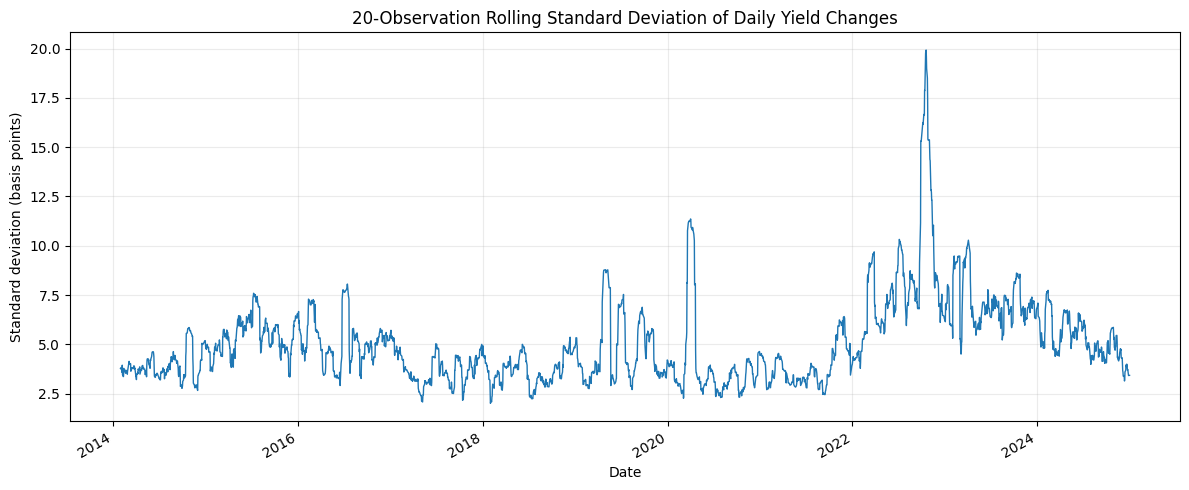

In [65]:
boe_clean["rolling_20d_std_bps"] = (
    boe_clean["yield_change_bps"]
    .rolling(window=20)
    .std()
)

fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(
    boe_clean["date"],
    boe_clean["rolling_20d_std_bps"],
    linewidth=1
)

ax.set_title("20-Observation Rolling Standard Deviation of Daily Yield Changes")
ax.set_xlabel("Date")
ax.set_ylabel("Standard deviation (basis points)")
ax.grid(alpha=0.25)

fig.autofmt_xdate()
plt.tight_layout()
plt.show()


### Final data-understanding summary

In [66]:
summary = {
    "series_code": YIELD_COL,
    "observations": len(boe_clean),
    "start_date": boe_clean["date"].min().date(),
    "end_date": boe_clean["date"].max().date(),
    "missing_yields_after_cleaning": int(boe_clean["yield_10y"].isna().sum()),
    "duplicate_dates_after_cleaning": int(boe_clean["date"].duplicated().sum()),
    "mean_yield_percent": boe_clean["yield_10y"].mean(),
    "min_yield_percent": boe_clean["yield_10y"].min(),
    "max_yield_percent": boe_clean["yield_10y"].max(),
    "largest_absolute_daily_move_bps": boe_clean["yield_change_bps"].abs().max(),
}

pd.Series(summary)

series_code                        Yield from British Government Securities, 10 y...
observations                                                                    2779
start_date                                                                2014-01-02
end_date                                                                  2024-12-31
missing_yields_after_cleaning                                                      0
duplicate_dates_after_cleaning                                                     0
mean_yield_percent                                                          1.913977
min_yield_percent                                                             0.1114
max_yield_percent                                                             4.6651
largest_absolute_daily_move_bps                                                38.24
dtype: object

In [67]:
PROCESSED_DIR = Path("data") / "processed"
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

processed_path = PROCESSED_DIR / "boe_10y_zero_coupon_clean.csv"

boe.to_csv(
    processed_path,
    index=False
)

print(f"Saved cleaned dataset to: {processed_path}")

Saved cleaned dataset to: data/processed/boe_10y_zero_coupon_clean.csv


#### Rolling Volatility of Daily Yield Changes

The 20-observation rolling standard deviation shows clear changes in yield volatility over time. For most of the period before 2022, volatility remained relatively low, generally around 3–6 basis points, with a few temporary spikes. Volatility rose sharply during 2022 and reached its highest level at around 20 basis points, consistent with the extreme daily yield movements seen during the LDI crisis. It remained elevated through much of 2023 and 2024 before gradually declining. This provides further evidence of volatility clustering, where large yield movements tend to occur in concentrated periods rather than being evenly distributed over time.